<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
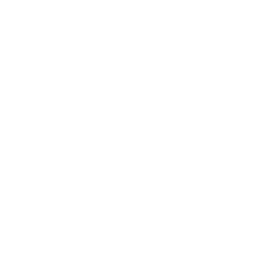
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Clustering delle modalità di guasto nella produzione</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Produzione / Ingegneria della qualità &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi esecutiva

Questo esempio scopre le **modalità di guasto ricorrenti delle apparecchiature** a partire dal profilo multidimensionale dei sintomi rilevati dai sensori a ciascun evento di guasto. Otto variabili di sintomo standardizzate (vibrazione, delta di temperatura, calo di pressione, picco di corrente, rumore, deviazione del tempo di ciclo, varianza di coppia, conteggio delle particelle nell'olio) vengono raggruppate con il **clustering gerarchico a legame completo** (`PROC CLUSTER METHOD=COMPLETE`), che favorisce gruppi compatti e ben separati. `PROC TREE` taglia poi la gerarchia in **sei modalità di guasto**, e `PROC FREQ` tabula in modo incrociato tali modalità rispetto al tipo di apparecchiatura e al turno per verificare associazioni sistematiche.

L'esecuzione qui avviene su un **campione di 100 eventi** (l'ambiente limita l'output a 100 osservazioni). Su questo campione le sei modalità sono all'incirca di uguale dimensione (n = 16-17 ciascuna) e sono separate principalmente dalle firme di **temperatura, pressione e vibrazione** anziché dal tipo di apparecchiatura — le tabulazioni incrociate modalità-per-apparecchiatura e modalità-per-turno **non** sono statisticamente significative a questa dimensione campionaria (chi-quadrato p = 0.15 e p = 0.07 rispettivamente). Il flusso di lavoro scala invariato all'intera cronologia degli eventi, dove conteggi per modalità più grandi renderebbero più nitide queste associazioni.

## Fonti dei dati

| Fonte | Descrizione | Record |
|--------|-------------|---------|
| WORK.FAILURES | Profili dei sintomi degli eventi di guasto delle apparecchiature (sintetici) | 100 |
| WORK.FAILURES_STD | Sintomi standardizzati a media 0, dev. std 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Cronologia delle fusioni a legame completo (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Taglio a sei modalità da `PROC TREE NCLUSTERS=6` | 100 |

*Questo ambiente funziona in modalità senza licenza e limita l'output a 100 osservazioni; il generatore sintetico richiede 20.000 eventi ma solo i primi 100 vengono conservati. L'analisi seguente si basa interamente su quel campione di 100 eventi.*

---

In [1]:
/* --------------------------------------------------------
   Genera profili sintetici di sintomi degli eventi di guasto
   20.000 eventi di guasto su 50 unità di apparecchiature
   -------------------------------------------------------- */
DATI work.failures;
    CHIAMARE streaminit(42);
    LUNGHEZZA equipment_type $16 shift $8;
    VETTORE equip_type_list[4] $16 _temporary_ ('PRESSA' 'NASTRO' 'BRACCIO_ROBOT' 'FORNO');
    VETTORE shift_list[3] $8 _temporary_ ('GIORNO' 'SERA' 'NOTTE');
    FARE event_id = 1 FINO_A 20000;
        failure_id = cat('FE-', PUT(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', PUT(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Profilo dei sintomi: 8 letture dei sensori al momento del guasto */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        SE_COND vibration_level < 0 ALLORA vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        SE_COND current_spike < 0 ALLORA current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        USCITA;
    FINE;
    RIMUOVERE equip_num etype_idx shift_idx;
    FORMATO failure_date date9.;
    ETICHETTA failure_id="ID guasto"
          equipment_id="ID apparecchiatura"
          equipment_type="Tipo di apparecchiatura"
          shift="Turno"
          failure_date="Data guasto"
          vibration_level="Livello di vibrazione"
          temperature_delta="Delta di temperatura (C)"
          pressure_drop="Calo di pressione"
          current_spike="Picco di corrente"
          noise_db="Rumore (dB)"
          cycle_time_deviation="Deviazione tempo ciclo"
          torque_variance="Varianza di coppia"
          oil_particle_count="Conteggio particelle olio"
          downtime_minutes="Minuti di fermo";
ESEGUIRE;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  6.28 seconds
  cpu   6.28 seconds


---

In [2]:
/* --------------------------------------------------------
   Distribuzioni di base dei sintomi per tipo di apparecchiatura
   -------------------------------------------------------- */
PROCEDURA MEDIE DATI=work.failures n mean std MAX;
    CLASSE equipment_type;
    VARIABILE vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    ETICHETTA equipment_type="Tipo di apparecchiatura"
          vibration_level="Livello di vibrazione"
          temperature_delta="Delta di temperatura (C)"
          pressure_drop="Calo di pressione"
          current_spike="Picco di corrente"
          noise_db="Rumore (dB)"
          torque_variance="Varianza di coppia"
          oil_particle_count="Conteggio particelle olio";
    TITOLO "Profili dei sintomi di guasto per tipo di apparecchiatura";
ESEGUIRE;

                               Profili dei sintomi di guasto per tipo di apparecchiatura                                

                                                  The MEANS Procedure

                               Analysis Variable : vibration_level Livello di vibrazione

        Tipo di apparecchiatura          N Obs           Mean        Std Dev        Maximum
        -----------------------------------------------------------------------------------
        BRACCIO_ROBOT                       25      3.5320000      1.9296070      6.7900000
        FORNO                               26      4.3638462      2.0371177     10.1400000
        NASTRO                              19      3.8089474      1.8662437      9.0400000
        PRESSA                              30      4.6273333      2.1610740      9.9400000
        -----------------------------------------------------------------------------------

                             Analysis Variable : temperature_delta Delta


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                               Profili dei sintomi di guasto per tipo di apparecchiatura                                




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


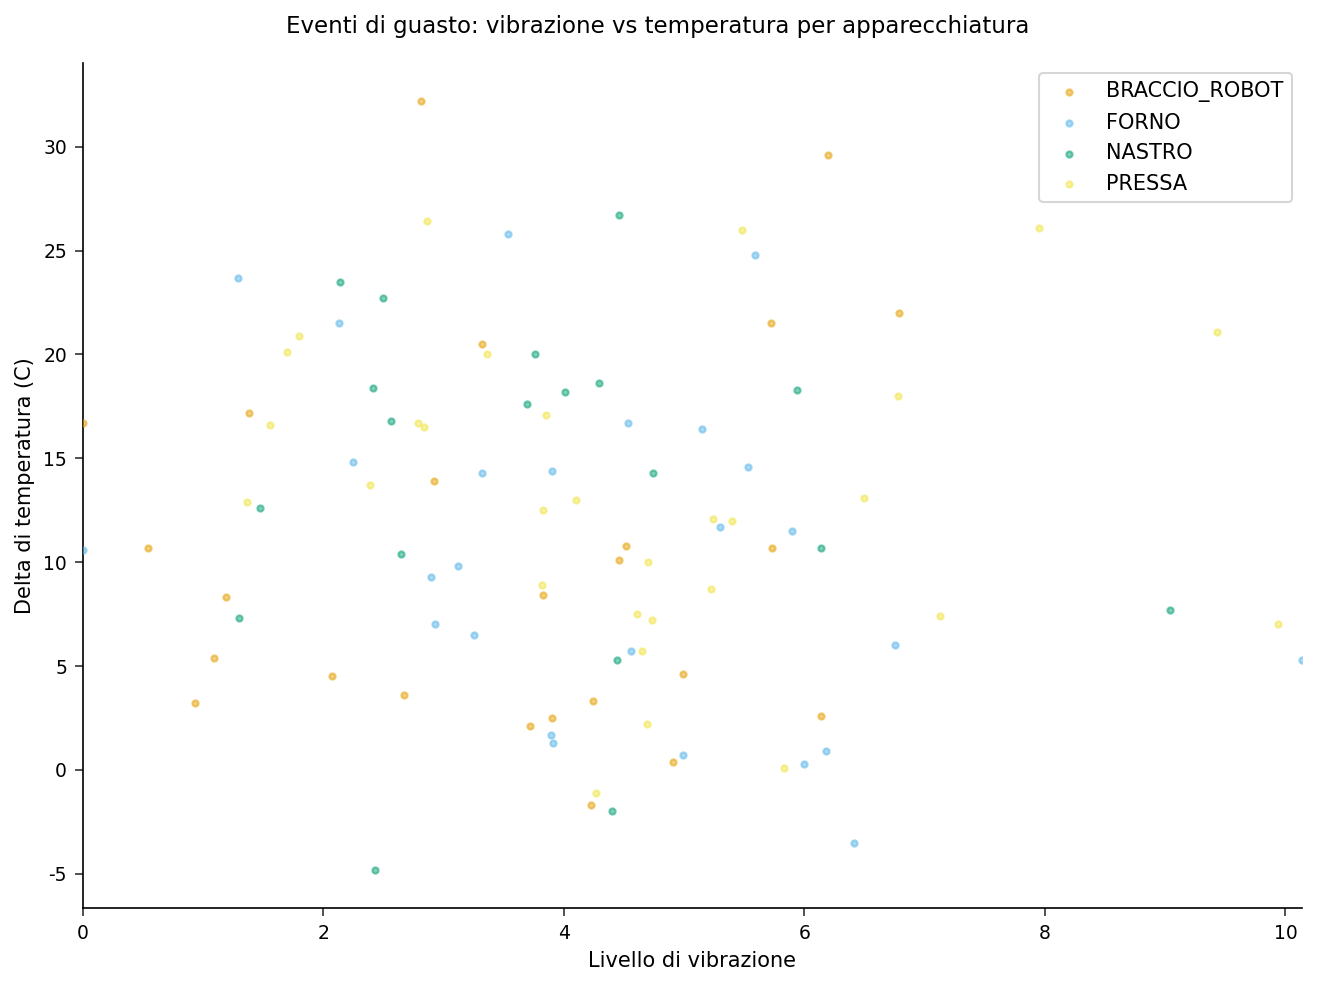

In [3]:
/* --------------------------------------------------------
   Vibrazione vs delta di temperatura per tipo di apparecchiatura
   -------------------------------------------------------- */
PROCEDURA SGPLOT DATI=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS ETICHETTA="Livello di vibrazione";
    YAXIS ETICHETTA="Delta di temperatura (C)";
    TITOLO "Eventi di guasto: vibrazione vs temperatura per apparecchiatura";
ESEGUIRE;

---

In [4]:
/* --------------------------------------------------------
   Standardizza le variabili di sintomo per il clustering
   -------------------------------------------------------- */
PROCEDURA STANDARD DATI=work.failures out=work.failures_std
    mean=0 std=1;
    VARIABILE vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
ESEGUIRE;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                               Profili dei sintomi di guasto per tipo di apparecchiatura                                

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


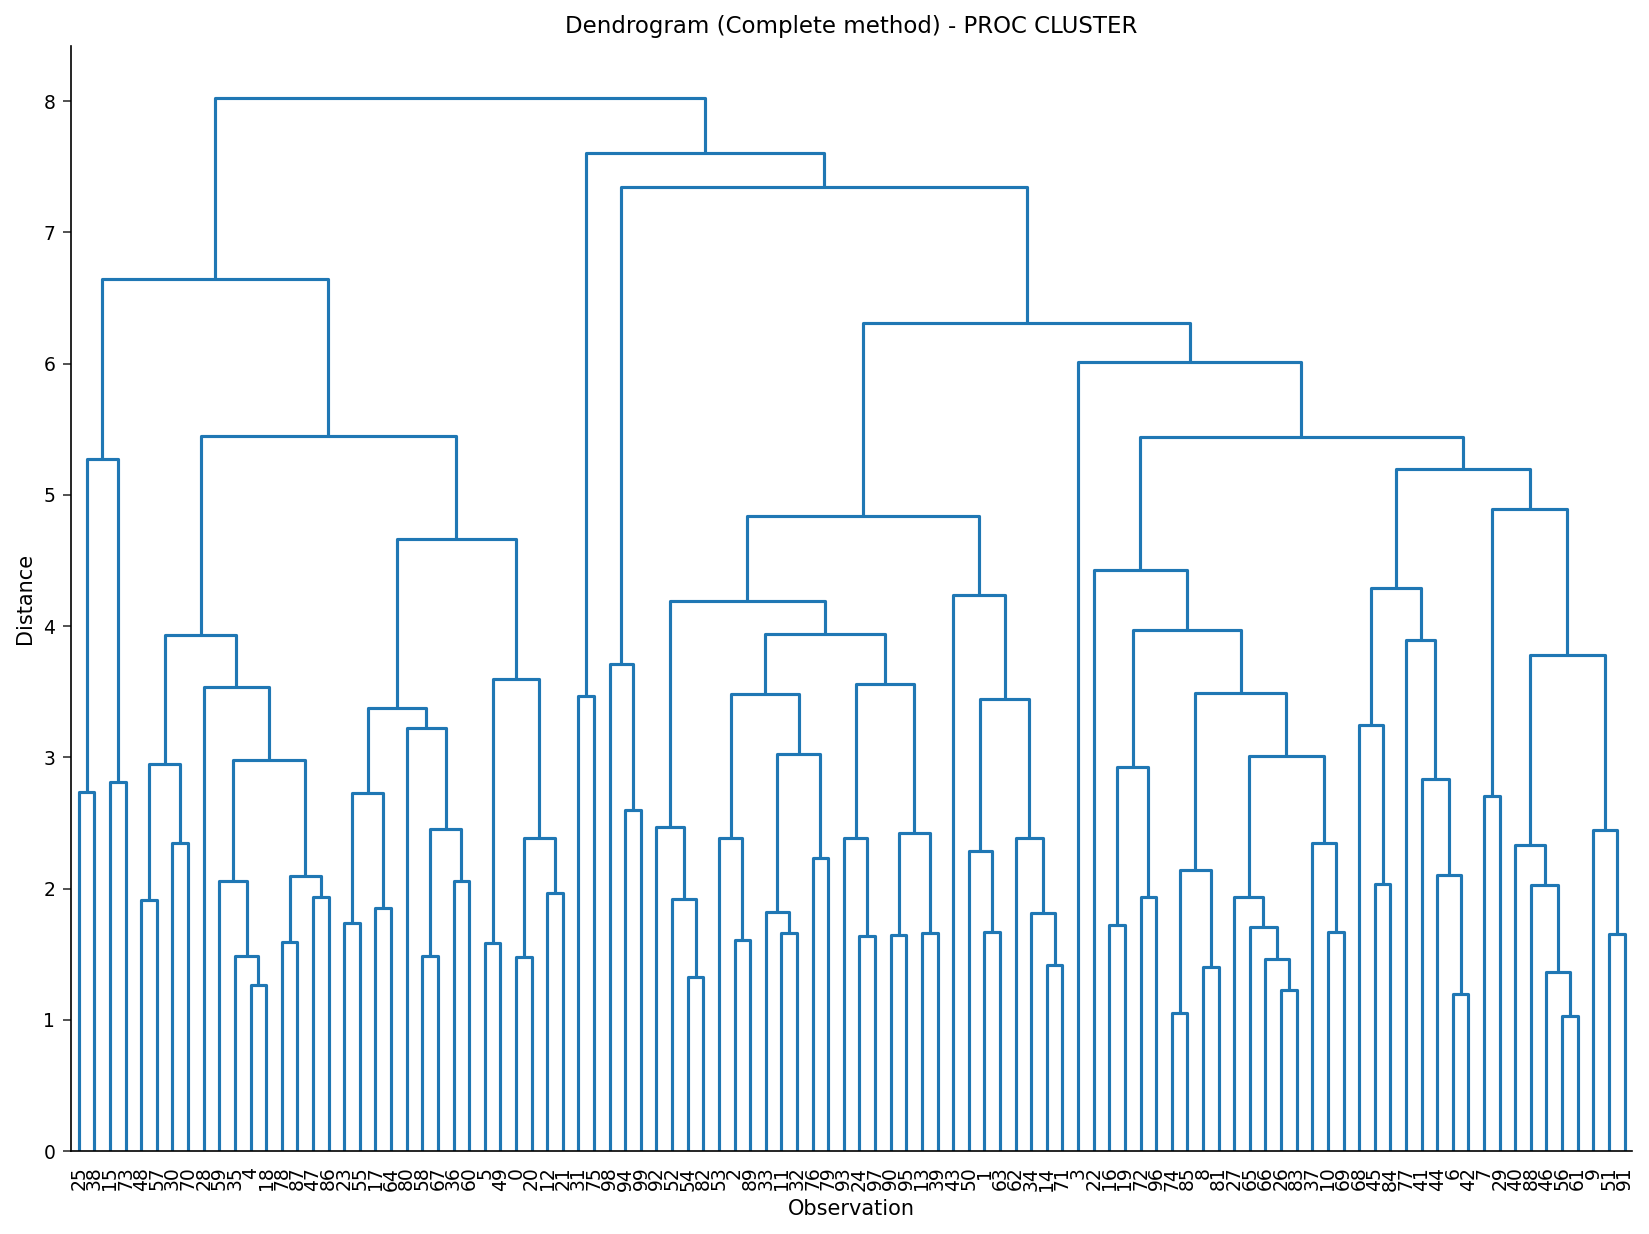

In [5]:
/* --------------------------------------------------------
   Clustering a legame completo con TRIM= per la rimozione
   degli outlier. TRIM=5 rimuove il 5% delle osservazioni
   più distanti prima di formare i cluster.
   -------------------------------------------------------- */
PROCEDURA CLUSTER DATI=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo STAMPARE=20 trim=5;
    VARIABILE vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
ESEGUIRE;

In [6]:
/* --------------------------------------------------------
   Taglia la gerarchia a legame completo in sei modalità di
   guasto con PROC TREE (NCLUSTERS=6). Sei è scelto come
   granularità pratica e interpretabile per il triage; il
   dendrogramma sopra mostra la struttura di fusione che
   questo taglio partiziona.
   -------------------------------------------------------- */
PROCEDURA TREE DATI=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
ESEGUIRE;

                               Profili dei sintomi di guasto per tipo di apparecchiatura                                




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Unisce le assegnazioni e profila le modalità di guasto
   -------------------------------------------------------- */
DATI work.failures_classified;
    UNIRE work.failures
          work.failure_mode_assignments(RINOMINARE=(CLUSTER=failure_mode));
    PER failure_id;
ESEGUIRE;

PROCEDURA MEDIE DATI=work.failures_classified n mean std;
    CLASSE failure_mode;
    VARIABILE vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    ETICHETTA failure_mode="Modalità di guasto"
          vibration_level="Livello di vibrazione"
          temperature_delta="Delta di temperatura (C)"
          pressure_drop="Calo di pressione"
          current_spike="Picco di corrente"
          noise_db="Rumore (dB)"
          torque_variance="Varianza di coppia"
          oil_particle_count="Conteggio particelle olio"
          downtime_minutes="Minuti di fermo";
    TITOLO "Profili dei sintomi per modalità di guasto (k=6)";
ESEGUIRE;

                                    Profili dei sintomi per modalità di guasto (k=6)                                    

                                                  The MEANS Procedure

                               Analysis Variable : vibration_level Livello di vibrazione

        Modalità di guasto           N Obs           Mean        Std Dev
        ----------------------------------------------------------------
        1                               17      4.3470588      2.6168582
        2                               17      4.2552941      2.2610427
        3                               17      3.6870588      1.8669720
        4                               17      4.0500000      2.0351843
        5                               16      3.4793750      1.4636870
        6                               16      4.9693750      1.6907177
        ----------------------------------------------------------------

                             Analysis Variable : temperatur


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                           Distribuzione delle modalità di guasto per apparecchiatura e turno                           

                                                   The FREQ Procedure

Table of Modalità di guasto by Tipo di apparecchiatura

Modalità di guasto  |BRACCIO_ROBOT |        FORNO |       NASTRO |       PRESSA |         Total
--------------------+--------------+--------------+--------------+--------------+--------------
1                   |            1 |            5 |            4 |            7 |            17
--------------------+--------------+--------------+--------------+--------------+--------------
2                   |            7 |            5 |            3 |            2 |            17
--------------------+--------------+--------------+--------------+--------------+--------------
3                   |            4 |            5 |            6 |            2 |            17
--------------------+--------------+--------------+--------------+-------------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


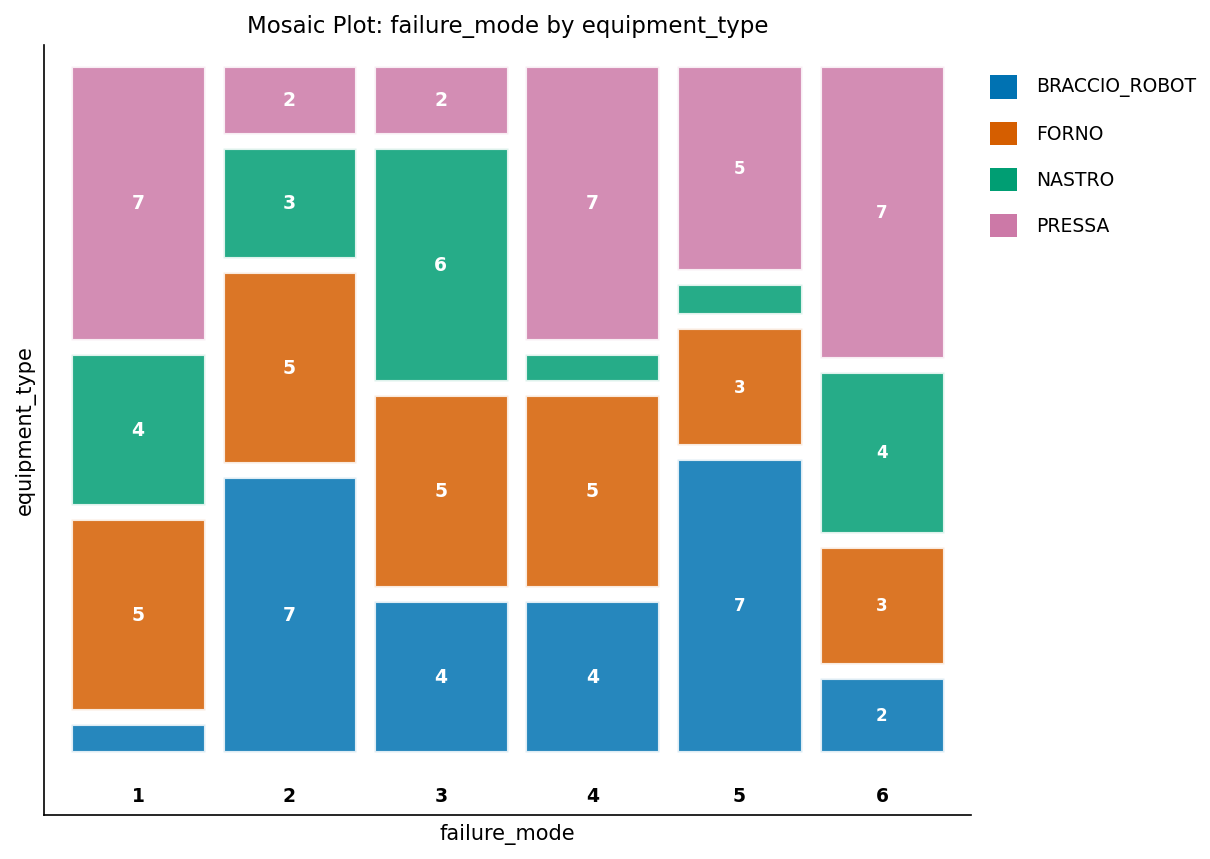

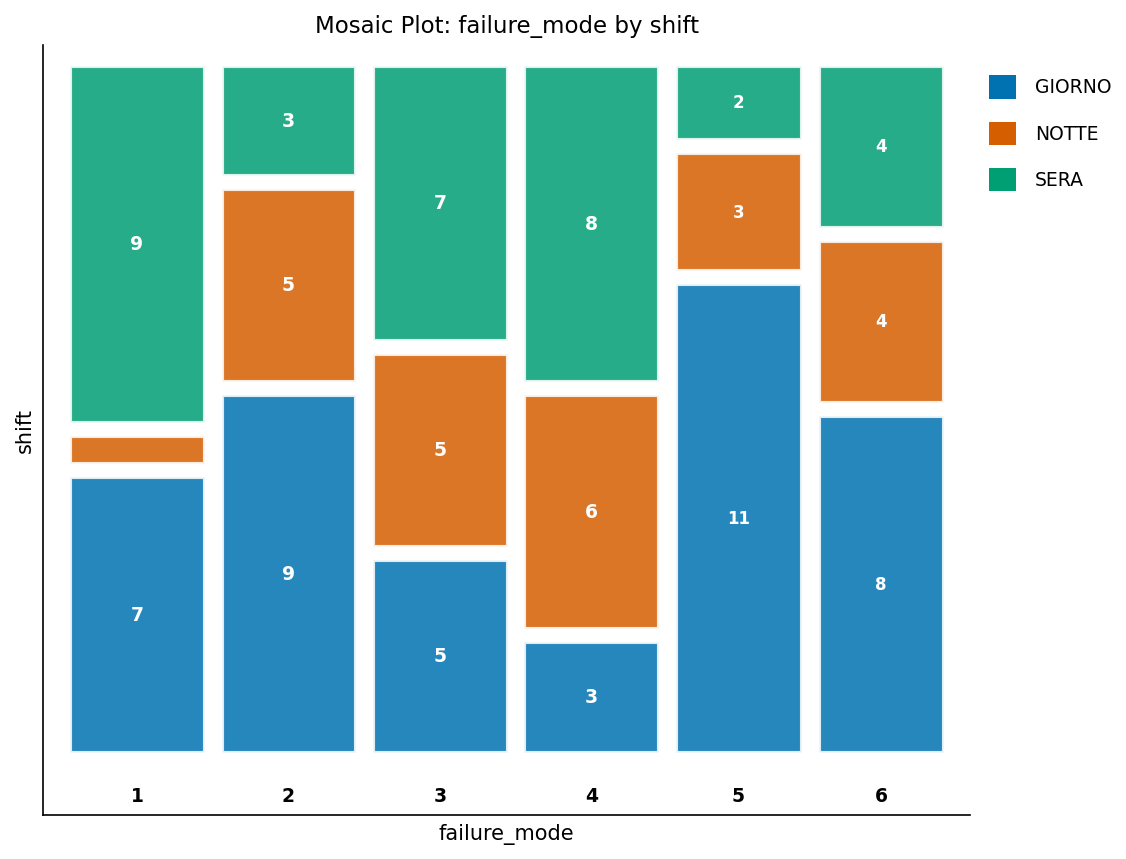

In [8]:
/* --------------------------------------------------------
   Tabulazione incrociata delle modalità di guasto per tipo
   di apparecchiatura e turno per individuare pattern sistematici
   -------------------------------------------------------- */
PROCEDURA FREQUENZE DATI=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    ETICHETTA failure_mode="Modalità di guasto"
          equipment_type="Tipo di apparecchiatura"
          shift="Turno";
    TITOLO "Distribuzione delle modalità di guasto per apparecchiatura e turno";
ESEGUIRE;

---

### Interpretazione

Il clustering a legame completo dei 100 eventi di guasto standardizzati produce **sei modalità di guasto** di dimensione quasi uguale (n = 17, 17, 17, 17, 16, 16). Le modalità si distinguono per le loro firme di sintomi nel profilo `PROC MEANS` qui sopra:

- **La Modalità 6** porta la firma di stress meccanico più pesante: vibrazione media più alta (4.97), calo di pressione più alto (7.51) e picco di corrente più alto (1.61) — ma la varianza di coppia **più bassa** (1.28).
- **La Modalità 3** è la modalità termica: delta di temperatura più alto (16.3 C) con il rumore medio più basso (73.0 dB).
- **La Modalità 2** ha il **tempo di fermo più lungo** con ampio margine (media 85.6 minuti contro 31-52 per le altre modalità) e varianza di coppia elevata (3.57), indicando eventi il cui recupero è più costoso.
- **La Modalità 4** è la più lieve: tempo di fermo più basso (31.4 minuti) e calo di pressione e conteggio delle particelle nell'olio inferiori alla media.
- **Le Modalità 1 e 5** sono gruppi a sintomi misti senza un singolo fattore dominante.

Le tabulazioni incrociate `PROC FREQ` verificano se queste modalità si concentrano in particolari apparecchiature o turni. A questa dimensione campionaria **non** lo fanno: modalità-per-tipo-di-apparecchiatura dà chi-quadrato = 20.48 (15 gdl, p = 0.154, V di Cramer = 0.26) e modalità-per-turno dà chi-quadrato = 17.13 (10 gdl, p = 0.072, V di Cramer = 0.29) — entrambi sopra la soglia di 0.05, e oltre l'80% delle celle ha conteggi attesi inferiori a 5, quindi il chi-quadrato stesso è solo indicativo. Le inclinazioni visibili (la Modalità 6 che tende verso PRESSA, la Modalità 5 verso il turno diurno) sono qui descrittive anziché significative.

**Conclusione:** il legame completo sui profili di sintomi standardizzati produce una tassonomia interpretabile a sei modalità legata a temperatura, pressione e tempo di fermo. Per confermare se le modalità corrispondano ad apparecchiature o turni specifici — la domanda operativa sulla causa radice — l'analisi necessita dell'intera cronologia degli eventi anziché di questo campione di 100 eventi, dove le tabulazioni incrociate restano sottodimensionate.

---

In [9]:
/* --------------------------------------------------------
   Esporta le classificazioni di guasto per l'integrazione CMMS
   -------------------------------------------------------- */
PROCEDURA EXPORT DATI=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
ESEGUIRE;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Riservato
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Realizzato con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>